# TraceDNA

A failing run is frozen into a capsule. The capsule is then used as the fixed
environment for an experiment: remove one method from the source, replay, and see
whether the failure still happens. A method whose removal makes the failure disappear
is a method the failure depends on.

This notebook runs that pipeline on `examples/Payments.java` and draws the result.
It needs a Rust toolchain and a JDK on `PATH`.

In [1]:
import pathlib, subprocess

ROOT = pathlib.Path.cwd().parent
TRACEDNA = ["cargo", "run", "--release", "--quiet", "--"]

def tracedna(*args):
    done = subprocess.run(TRACEDNA + list(args), cwd=ROOT, capture_output=True, text=True)
    print(done.stdout, done.stderr, sep="")

tracedna("capture", "subject.capsule")
tracedna("analyze", "failure.capsule")

payment 0: amount=100 fee=10
payment 1: amount=100 fee=13
payment 2: amount=100 fee=6
payment 3: amount=100 fee=9
payment 4: amount=100 fee=11
payment 6: amount=100 fee=7
payment 7: amount=100 fee=10
no BRL rate for bracket 98

captured after 12 runs -> failure.capsule



bracket      yes
rate         yes
fee          no
format       no
log          no

written to failure.capsule



In [2]:
capsule = {}
for line in (ROOT / "failure.capsule").read_text().splitlines():
    if "=" in line and not line.startswith("#"):
        key, value = line.split("=", 1)
        capsule[key.strip()] = value.strip()

needs = {key[len("needs."):]: value for key, value in capsule.items() if key.startswith("needs.")}
print(capsule["error"], "| seed", capsule["seed"], "|", capsule["env.CURRENCY"])
needs

no BRL rate for bracket 98 | seed 68187 | BRL


{'bracket': 'yes', 'fee': 'no', 'format': 'no', 'log': 'no', 'rate': 'yes'}

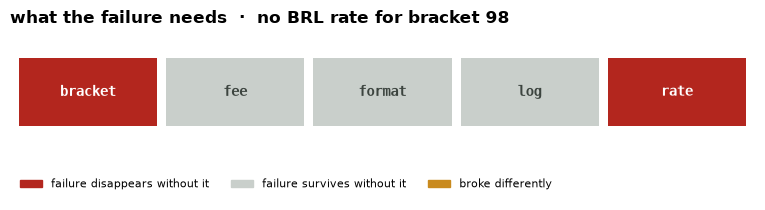

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLOR = {"yes": "#b3261e", "no": "#c9cfcb", "inconclusive": "#c98a1e"}

fig, ax = plt.subplots(figsize=(1.55 * len(needs), 2.2))
for position, (method, verdict) in enumerate(needs.items()):
    ax.barh(0, 0.94, left=position, height=1, color=COLOR[verdict])
    ax.text(position + 0.47, 0, method, ha="center", va="center", color="white" if verdict == "yes" else "#3c443f",
            fontfamily="monospace", fontsize=10, fontweight="bold")

ax.set_xlim(-0.06, len(needs))
ax.set_ylim(-1.6, 0.9)
ax.axis("off")
ax.set_title(f"what the failure needs  ·  {capsule['error']}", loc="left", fontweight="bold")
ax.legend(handles=[Patch(color=COLOR["yes"], label="failure disappears without it"),
                   Patch(color=COLOR["no"], label="failure survives without it"),
                   Patch(color=COLOR["inconclusive"], label="broke differently")],
          loc="lower left", frameon=False, ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

Two methods out of five carry the failure: `bracket`, which decides which fee bracket a
payment lands in, and `rate`, which looks that bracket up. That is exactly where the bug
is — the BRL rate table has no entry above bracket 96. `fee`, `format` and `log` run
during the failure but are not part of it.

The whole finding lives in the capsule as plain text, so it can be committed and diffed
next to the fix.